# Orientação Política Através do Discurso
Como Posicionar Falas de Deputados em Meio às Orientações Partidárias?

---

João Pedro Rodrigues Vieira - 10403595


## 0. Preparação do Ambiente

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import re
import nltk
import torch
import string
import uuid
import unicodedata
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.stem import RSLPStemmer
from nltk.corpus import stopwords
from transformers import set_seed
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from nltk.tokenize import word_tokenize
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import Normalizer
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import balanced_accuracy_score, classification_report, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, cross_val_predict, cross_validate

## 1. Datasets e Transformação dos Dados

### 1.1. Notícias que descrevem o posicionamento do partido com relação ao tema

In [3]:
news_path = "content/noticia_partidos.jsonl"

news_df = pd.read_json(news_path, lines=True)
print('Linhas x Colunas:', news_df.shape)
news_df.head()

Linhas x Colunas: (1061, 7)


,titulo,texto_cru,data_publicacao,link,keywords_encontradas,fonte_descoberta,partido
0,Câmara dos Deputados aprova aumento da pena de...,"Nesta última quarta-feira (11), a Câmara dos D...",2024-09-12,https://avante70.org.br/noticias/camara-dos-de...,"[arma, arma de fogo]",wp-api,AVANTE
1,Manaus reforça liderança nacional em segurança...,"O prefeito de Manaus, David Almeida (Avante), ...",2025-12-04,https://avante70.org.br/noticias/manaus-reforc...,"[arma, pistola, municao, calibre, arma de fogo]",wp-api,AVANTE
2,Deputada federal Greyce Elias é relatora de PL...,"A Câmara dos Deputados aprovou, nesta terça-fe...",2021-04-14,https://avante70.org.br/noticias/deputada-fede...,"[armas, porte de armas]",wp-api,AVANTE
3,Projeto da deputada Greyce Elias permite uso d...,A deputada federal Greyce Elias (Avante/MG) ap...,2021-07-01,https://avante70.org.br/noticias/projeto-da-de...,"[armas, armas de fogo]",wp-api,AVANTE
4,Carlos Cavalcante cobra maior policiamento,Carlos Cavalcante relata casos de violência e ...,2009-11-12,https://avante70.org.br/noticias/carlos-cavalc...,"[arma, arma de fogo]",wp-api,AVANTE


### 1.2. Base de discursos da câmara dos deputados

In [4]:
discourses_path = "content/firearm-carry-speeches-2014-2026.jsonl"

discourse_df = pd.read_json(discourses_path, lines=True)
print('Linhas x Colunas:', discourse_df.shape)
discourse_df.head()

Linhas x Colunas: (256, 20)


,id,event_id,deputy_id,deputy_name,party,political_spectrum,ideological_stance,state,legislature_id,speech_type,keywords,transcript,summary,start_date,end_date,major_claim,micro_arguments,topic_consistency,is_argumentative,stance
0,a660973a-7e8f-422e-ac12-3d85e2ca27aa,35538,167614,Severino Ninho,PSB,Centro-esquerda,Progressista,PE,54,ORIENTAÇÃO DE BANCADA,"PL 6565/2013, PROJETO DE LEI, CONCESSÃO, PORTE...",O SR. SEVERINO NINHO (PSB-PE. Pela ordem. Sem ...,Orientação de bancada favorável do PSB ao Proj...,2014-03-26T14:00,2014-03-26T20:28,o PSB também vota a favor do projeto,[{'claim': 'alertando nossos queridos guardas ...,TOPIC,True,PRO
1,9bf5cbca-b734-421d-852e-54d48b21079d,35538,4931,Izalci,PSDB,Centro,Neutro,DF,54,ORIENTAÇÃO DE BANCADA,"PL 6565/2013, PROJETO DE LEI, CONCESSÃO, PORTE...",O SR. IZALCI (PSDB-DF. Pela ordem. Sem revisão...,Orientação de bancada favorável do PSDB ao Pro...,2014-03-26T14:00,2014-03-26T20:28,o PSDB vota pela aprovação do projeto,[{'claim': 'Os agentes e guardas prisionais pr...,TOPIC,True,PRO
2,1152aead-d96e-475b-8b09-bcbf9010d313,35538,73466,Rubens Bueno,PPS,,,PR,54,PELA ORDEM,"PL 6565/2013, PROJETO DE LEI, CONCESSÃO, PORTE...",O SR. RUBENS BUENO (PPS-PR. Pela Ordem. Sem re...,"Ponderações sobre o Projeto de Lei nº 6.565, d...",2014-03-26T14:00,2014-03-26T20:28,O PPS vota favoravelmente.,[{'claim': 'Nós também estamos de acordo com q...,TOPIC,True,PRO
3,4962cc8d-5fad-43a4-abdf-1c443171f23e,35538,73433,Arlindo Chinaglia,PT,Esquerda,Progressista,SP,54,PELA ORDEM,"PL 6565/2013, PROJETO DE LEI, CONCESSÃO, PORTE...",O SR. ARLINDO CHINAGLIA (PT-SP. Pela ordem. Se...,Solicitação à bancada do PT de retirada de req...,2014-03-26T14:00,2014-03-26T20:28,nós caminharemos para a votação de acordo com ...,"[{'claim': 'eu quero, então, propor e pedir à ...",TOPIC,True,NEUTRAL
4,1a79dbf5-a338-4deb-8ee2-646cc7b19b87,35538,74848,Jandira Feghali,PCDOB,Esquerda,Progressista,RJ,54,ORIENTAÇÃO DE BANCADA,"PL 6565/2013, PROJETO DE LEI, CONCESSÃO, PORTE...",A SRA. JANDIRA FEGHALI (PCdoB-RJ. Pela ordem. ...,Orientação de bancada favorável do PC do B ao ...,2014-03-26T14:00,2014-03-26T20:28,"O PCdoB vota ""sim"" ao projeto.",[{'claim': 'entendemos que é correto colocar n...,TOPIC,True,PRO


### 1.3. Metadados
A EDA começa conhecendo a estrutura: quantas linhas/colunas, tipos e valores faltantes.


In [5]:
news_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   titulo                1061 non-null   str   
 1   texto_cru             1061 non-null   str   
 2   data_publicacao       1061 non-null   str   
 3   link                  1061 non-null   str   
 4   keywords_encontradas  1061 non-null   object
 5   fonte_descoberta      1061 non-null   str   
 6   partido               1061 non-null   str   
dtypes: object(1), str(6)
memory usage: 58.2+ KB


In [6]:
discourse_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  256 non-null    str   
 1   event_id            256 non-null    int64 
 2   deputy_id           256 non-null    int64 
 3   deputy_name         256 non-null    str   
 4   party               256 non-null    str   
 5   political_spectrum  256 non-null    str   
 6   ideological_stance  256 non-null    str   
 7   state               256 non-null    str   
 8   legislature_id      256 non-null    int64 
 9   speech_type         256 non-null    str   
 10  keywords            256 non-null    str   
 11  transcript          256 non-null    str   
 12  summary             256 non-null    str   
 13  start_date          256 non-null    str   
 14  end_date            256 non-null    str   
 15  major_claim         256 non-null    str   
 16  micro_arguments     256 non-null    o

In [7]:
print("Valores nulos por coluna em news_df:")
news_nulls = news_df.isna().sum().rename("quantidade_nulos")
print(news_nulls.to_frame())

print("\nValores nulos por coluna em discourse_df:")
discourse_nulls = discourse_df.isna().sum().rename("quantidade_nulos")
print(discourse_nulls.to_frame())

Valores nulos por coluna em news_df:
                      quantidade_nulos
titulo                               0
texto_cru                            0
data_publicacao                      0
link                                 0
keywords_encontradas                 0
fonte_descoberta                     0
partido                              0

Valores nulos por coluna em discourse_df:
                    quantidade_nulos
id                                 0
event_id                           0
deputy_id                          0
deputy_name                        0
party                              0
political_spectrum                 0
ideological_stance                 0
state                              0
legislature_id                     0
speech_type                        0
keywords                           0
transcript                         0
summary                            0
start_date                         0
end_date                           0
major_claim     

### 1.4. Obtendo argumentos

In [8]:
def get_argument(adu) -> str:
    parts = [adu["major_claim"]]

    for micro_argument in adu["micro_arguments"]:
        parts.append(micro_argument["claim"])

        for premise in micro_argument["premises"]:
            if premise.strip().upper() == "[IMPLICIT]":
                continue
            parts.append(premise)

    return " ".join(parts)

In [9]:
discourse_df["argument"] = discourse_df.apply(get_argument, axis=1);
discourse_df["argument"][0]

'o PSB também vota a favor do projeto alertando nossos queridos guardas e agentes penitenciários para a responsabilidade que se deve ter com uma arma na mão e também dentro de casa pelo risco aos familiares É preciso que quem recebe o porte de arma receba um treinamento sério O PSB se preocupa muito com essa questão de termos cada vez mais armas nas ruas É necessário que os próprios agentes de segurança prisional busquem esse treinamento para que a arma não se volte contra eles e não prejudique a sociedade'

### 1.5. Padronizando siglas partidárias nas notícias e atribuindo espectro político a cada uma delas

In [10]:
news_to_discourse_party = {
    "PARTIDO COMUNISTA BRASILEIRO": "PCB",
    "PARTIDO COMUNISTA DO BRASIL": "PCDOB",
    "PARTIDO DA SOCIAL DEMOCRACIA BRASILEIRA": "PSDB",
    "PARTIDO SOCIALISTA BRASILEIRO": "PSB",
    "PARTIDO VERDE": "PV",
    "REPUBLICANOS": "REPUBLICAN",
    "PARTIDO SOCIALISMO E LIBERDADE": "PSOL",
    "PARTIDO DOS TRABALHADORES": "PT",
    "PARTIDO DEMOCRÁTICO TRABALHISTA": "PDT",
    "PARTIDO SOCIAL DEMOCRÁTICO": "PSD",
    "PARTIDO NOVO": "NOVO",
    "CIDADANIA": "CIDADANIA",
    "MOVIMENTO DEMOCRÁTICO BRASILEIRO": "MDB",
    "PARTIDO LIBERAL": "PL",
    "UNIDADE POPULAR": "UP",
    "PARTIDO DA CAUSA OPERÁRIA": "PCO",
    "SOLIDARIEDADE": "SOLIDARIED",
    "AVANTE": "AVANTE",
    "PROGRESSISTAS": "PP",
    "DEMOCRACIA CRISTÃ": "DC",
    "REDE SUSTENTABILIDADE": "REDE",
}

news_df["partido"] = news_df["partido"].replace(news_to_discourse_party)

In [11]:
party_spectrum = {
    "AVANTE": "Centro",
    "CIDADANIA": "Centro-esquerda",
    "DC": "Centro-direita",
    "MDB": "Centro",
    "NOVO": "Direita",
    "PCB": "Extrema-esquerda",
    "PCDOB": "Esquerda",
    "PCO": "Extrema-esquerda",
    "PDT": "Centro-esquerda",
    "PL": "Centro-direita",
    "PP": "Centro-direita",
    "PSB": "Centro-esquerda",
    "PSD": "Centro",
    "PSDB": "Centro",
    "PSOL": "Esquerda",
    "PT": "Esquerda",
    "PV": "Centro-esquerda",
    "REDE": "Centro-esquerda",
    "REPUBLICAN": "Direita",
    "SOLIDARIED": "Centro-esquerda",
    "UP": "Extrema-esquerda",
}
news_df["espectro_politico"] = (
    news_df["partido"]
    .map(party_spectrum)
)

print(news_df[["partido", "espectro_politico"]].drop_duplicates().sort_values("partido"))
print("Notícias sem espectro:", news_df["espectro_politico"].isna().sum())

         partido espectro_politico
0         AVANTE            Centro
7      CIDADANIA   Centro-esquerda
29            DC    Centro-direita
30           MDB            Centro
595         NOVO           Direita
46           PCB  Extrema-esquerda
183        PCDOB          Esquerda
309          PCO  Extrema-esquerda
442          PDT   Centro-esquerda
577           PL    Centro-direita
951           PP    Centro-direita
703          PSB   Centro-esquerda
793          PSD            Centro
316         PSDB            Centro
625         PSOL          Esquerda
506           PT          Esquerda
855           PV   Centro-esquerda
954         REDE   Centro-esquerda
955   REPUBLICAN           Direita
1039  SOLIDARIED   Centro-esquerda
1044          UP  Extrema-esquerda
Notícias sem espectro: 0


### 1.6. Padronizando o espectro político dos discursos

In [12]:
print(news_df["espectro_politico"].unique())

<StringArray>
[          'Centro',  'Centro-esquerda',   'Centro-direita',
 'Extrema-esquerda',         'Esquerda',          'Direita']
Length: 6, dtype: str


In [13]:
print(discourse_df["political_spectrum"].unique())

<StringArray>
[ 'Centro-esquerda',           'Centro',                 '',
         'Esquerda',   'Centro-direita',          'Direita',
  'Extrema-direita', 'Extrema- direita']
Length: 8, dtype: str


Alguns discursos têm o espectro escrito com espaço ("Extrema- direita") ou vazio, no caso de deputados de siglas extintas ou renomeadas. A grafia é corrigida e os vazios são tratados.

In [14]:
print(discourse_df.loc[discourse_df["political_spectrum"] == "Extrema- direita", "party"])

99     PSC
125    PSC
Name: party, dtype: str


In [15]:
print(discourse_df.loc[discourse_df["political_spectrum"] == "", "party"].unique())

<StringArray>
['PPS', 'PMN', 'DEM', 'PR', 'PSL', 'PROS', 'SOLIDARIED', 'MISSÃO']
Length: 8, dtype: str


In [16]:
discourse_party_spectrum = {
    "PSL": "Direita",
    "DEM": "Centro-direita",
    "PR": "Centro-direita",
    "PROS": "Centro",
    "PMN": "Centro",
    "PPS": "Centro-esquerda",
    "SOLIDARIEDAD": "Centro-esquerda",
    "SOLIDARIED": "Centro-esquerda",
    "MISSÃO": "Direita"
}

discourse_df["political_spectrum"] = discourse_df["political_spectrum"].replace("Extrema- direita", "Extrema-direita")

In [17]:
missing_spectrum = (discourse_df["political_spectrum"] == "") | (discourse_df["political_spectrum"].isna())

discourse_df.loc[missing_spectrum, "political_spectrum"] = (
    discourse_df.loc[missing_spectrum, "party"]
    .map(discourse_party_spectrum)
)

discourse_df["political_spectrum"].value_counts()

political_spectrum
Centro-direita     74
Esquerda           73
Direita            45
Centro-esquerda    32
Centro             26
Extrema-direita     6
Name: count, dtype: int64

In [18]:
print(discourse_df["political_spectrum"].unique())

<StringArray>
['Centro-esquerda',          'Centro',        'Esquerda',  'Centro-direita',
         'Direita', 'Extrema-direita']
Length: 6, dtype: str


### 1.7. Discursos Duplicados

In [19]:
discourse_df["transcript_norm"] = (
    discourse_df["transcript"]
    .str.lower()
    .str.replace(r"\s+", " ", regex = True)
    .str.strip()
)

In [20]:
duplicated_transcript = discourse_df["transcript_norm"].duplicated(keep = False)

print(f"Registros com transcrição duplicada: {duplicated_transcript.sum()}")
print(f"Transcrições distintas entre eles: {discourse_df.loc[duplicated_transcript, "transcript_norm"].nunique()}")

discourse_df.loc[duplicated_transcript, "event_id"].value_counts()

Registros com transcrição duplicada: 104
Transcrições distintas entre eles: 52


event_id
58491    49
58528    49
75304     2
76809     2
81227     1
81282     1
Name: count, dtype: int64

In [21]:
discourse_df = discourse_df.drop_duplicates("transcript_norm", keep = "first").copy()
print(f"Discursos após remover duplicatas: {len(discourse_df)}")

Discursos após remover duplicatas: 204


### 1.8. Mascarando o partido do próprio deputado em seu discurso

In [22]:
party_names = {
    "AVANTE": ["Avante"],
    "CIDADANIA": ["Cidadania"],
    "DC": ["Democracia Cristã", "DC"],
    "MDB": ["Movimento Democrático Brasileiro", "MDB", "PMDB"],
    "NOVO": ["Partido Novo"],
    "PCB": ["Partido Comunista Brasileiro", "PCB"],
    "PCDOB": ["Partido Comunista do Brasil", "PCdoB", "PC do B"],
    "PCO": ["Partido da Causa Operária", "PCO"],
    "PDT": ["Partido Democrático Trabalhista", "PDT"],
    "PL": ["Partido Liberal", "PL"],
    "PP": ["Progressistas", "PP"],
    "PSB": ["Partido Socialista Brasileiro", "PSB"],
    "PSD": ["Partido Social Democrático", "PSD"],
    "PSDB": ["Partido da Social Democracia Brasileira", "PSDB"],
    "PSOL": ["Partido Socialismo e Liberdade", "PSOL"],
    "PT": ["Partido dos Trabalhadores", "PT"],
    "PV": ["Partido Verde", "PV"],
    "REDE": ["Rede Sustentabilidade", "REDE"],
    "REPUBLICAN": ["Republicanos", "Republican"],
    "SOLIDARIED": ["Solidariedade"],
    "UP": ["Unidade Popular", "UP"],
    "PSL": ["Partido Social Liberal", "PSL"],
    "DEM": ["Democratas", "DEM"],
    "PR": ["Partido da República", "PR"],
    "PROS": ["Partido Republicano da Ordem Social", "PROS"],
    "PMN": ["Partido da Mobilização Nacional", "PMN"],
    "PPS": ["Partido Popular Socialista", "PPS"],
    "SOLIDARIEDAD": ["Solidariedad"],
    "MISSÃO": ["Missão"],
}

In [23]:
def mask_own_party(row):
    names = [row["party"]] + party_names.get(row["party"], [])
    pattern = "|".join(re.escape(name) for name in names)
    
    return re.sub(rf"(?<!\w)({pattern})(?!\w)(?!\s*(\d|nº))", "partido", row["argument"])

In [24]:
discourse_df["argument_masked"] = discourse_df.apply(mask_own_party, axis = 1)

In [25]:
masked = discourse_df["argument"] != discourse_df["argument_masked"]

print(f"Argumentos que cita o próprio partido: {masked.sum()} de {len(discourse_df)} ({masked.mean():.1%})")
discourse_df.loc[masked, ["party", "argument", "argument_masked"]].head()

Argumentos que cita o próprio partido: 38 de 204 (18.6%)


,party,argument,argument_masked
0,PSB,o PSB também vota a favor do projeto alertando...,o partido também vota a favor do projeto alert...
1,PSDB,o PSDB vota pela aprovação do projeto Os agent...,o partido vota pela aprovação do projeto Os ag...
2,PPS,O PPS vota favoravelmente. Nós também estamos ...,O partido vota favoravelmente. Nós também esta...
3,PT,nós caminharemos para a votação de acordo com ...,nós caminharemos para a votação de acordo com ...
4,PCDOB,"O PCdoB vota ""sim"" ao projeto. entendemos que ...","O partido vota ""sim"" ao projeto. entendemos qu..."


## 2. Análise Exploratória (EDA)


### 2.1. Tamanho do texto em caracteres


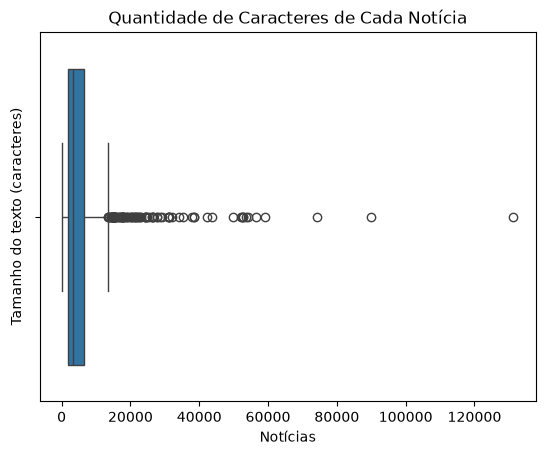

In [26]:
news_size = news_df['texto_cru'].fillna('').str.len()
sns.boxplot(news_df, x = news_size)
plt.title('Quantidade de Caracteres de Cada Notícia')
plt.xlabel("Notícias")
plt.ylabel('Tamanho do texto (caracteres)')
plt.show()

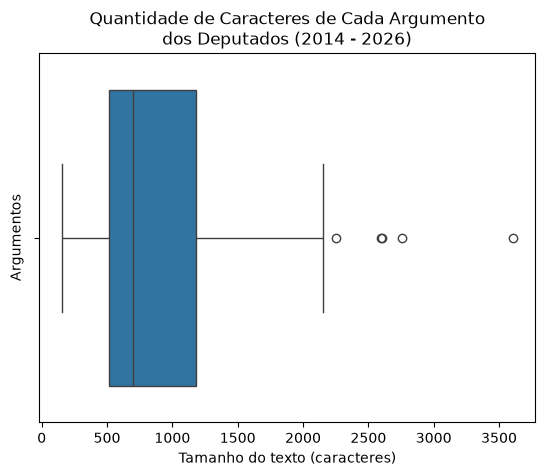

In [27]:
argument_size = discourse_df['argument'].str.len()
sns.boxplot(discourse_df, x = argument_size)
plt.title("Quantidade de Caracteres de Cada Argumento\ndos Deputados (2014 - 2026)")
plt.xlabel("Tamanho do texto (caracteres)")
plt.ylabel("Argumentos")
plt.show()

### 2.2. Um olhar sobre as palavras: quais termos melhor identificam o texto?

#### 2.2.1 TF-IDF

In [28]:
nltk.download("stopwords", quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download("rslp", quiet=True)

True

In [29]:
def preprocessing_text(text, stopwords_pt, stemmer = None) -> str:
    if not isinstance(text, str):
        return "";

    # NFC garante que palavras como "é" e "e" (escrita errada)
    # sejam entendidas da mesma forma
    text = unicodedata.normalize("NFC", text).lower()

    # Filtragem de links e e-mails
    text = re.sub(r"https?://\S+|www\.\S+", " ", text);
    text = re.sub(r"\S+@\S+", " ", text);

    # remoção de pontuações e caracteres especiais
    # espaços e acentuações são mantidas
    text = re.sub(r"[^\w\s]|[\d_]", " ", text);

    tokens = [t for t in text.split() if len(t) > 2 and t not in stopwords_pt]

    if stemmer is not None:
        tokens = [stemmer.stem(t) for t in tokens]

    return " ".join(tokens)

In [30]:
def tf_idf(
        text: pd.Series,
        stemming: bool = False,
        stopwords_extras: list | None = None,
        ngram_range: tuple = (1, 1),
        min_df: int | float = 1,
        max_df: int | float = 1.0
):
        sw = set(stopwords.words("portuguese"));

        if stopwords_extras:
                sw.update(stopwords_extras);

        sw = {unicodedata.normalize("NFC", p.lower()) for p in sw };

        stemmer = RSLPStemmer() if stemming else None;

        clean_texts = text.apply(lambda t: preprocessing_text(t, sw, stemmer));

        vectorizer = TfidfVectorizer(
                ngram_range = ngram_range,
                min_df = min_df,
                max_df = max_df,
                # \w com (?u) reconhece letras acentuadas
                token_pattern = r"(?u)\b\w+\b",
                # já é o padrão, mas aqui se faz explícito
                strip_accents=None
        );

        matrix = vectorizer.fit_transform(clean_texts);

        df_tfidf = pd.DataFrame(
                matrix.toarray(),
                index = text.index,
                columns = vectorizer.get_feature_names_out(),
        );

        ranking = df_tfidf.mean(axis = 0).sort_values(ascending = False);
        return df_tfidf, ranking, vectorizer

In [31]:
news_tfidf, news_tfidf_ranking, news_vectorizer = tf_idf(news_df["texto_cru"])

In [32]:
print(news_tfidf_ranking.head(10))

armas         0.038750
segurança     0.026282
governo       0.023771
brasil        0.023265
presidente    0.021753
fogo          0.021715
violência     0.021434
bolsonaro     0.021118
contra        0.020856
federal       0.020739
dtype: float64


In [33]:
discourse_tfidf, discourse_tfidf_ranking, discourse_vectorizer = tf_idf(discourse_df["argument"])

In [34]:
discourse_tfidf_ranking.head(10)

armas        0.055717
arma         0.043804
projeto      0.036761
segurança    0.034829
governo      0.027648
porte        0.026291
cidadão      0.025066
direito      0.024561
pública      0.024378
sim          0.023498
dtype: float64

### 2.3. Distribuição partidária

#### 2.3.1. Notícias

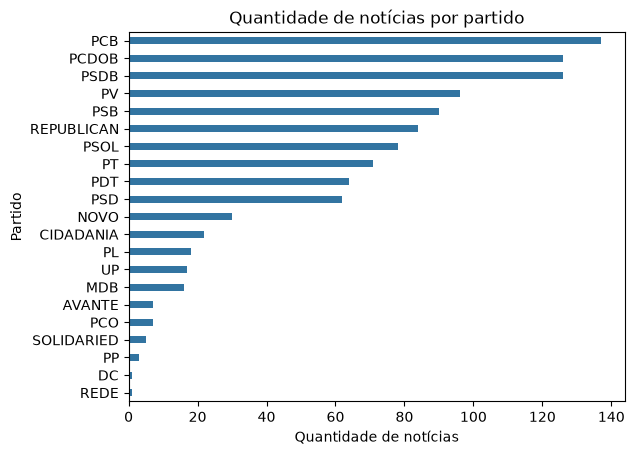

In [35]:
party_order = news_df["partido"].value_counts().index

sns.countplot(
    data=news_df,
    y="partido",
    order=party_order,
    gap=0.5,
)
plt.xlabel("Quantidade de notícias")
plt.ylabel("Partido")
plt.title("Quantidade de notícias por partido")
plt.show()

#### 2.3.2. Discursos

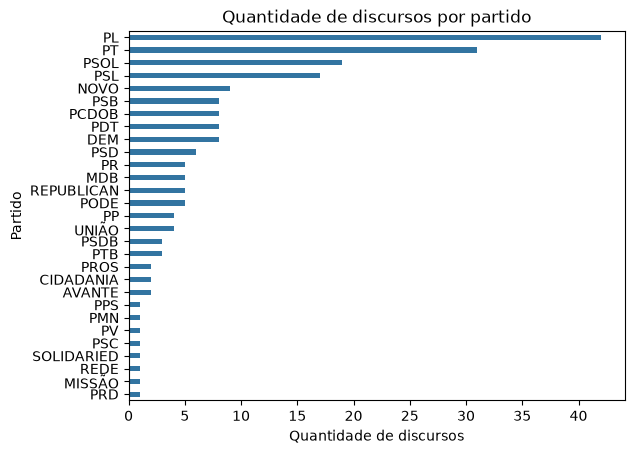

In [36]:
party_order = discourse_df["party"].value_counts().index

sns.countplot(
    data=discourse_df,
    y="party",
    order=party_order,
    gap=0.5,
)
plt.xlabel("Quantidade de discursos")
plt.ylabel("Partido")
plt.title("Quantidade de discursos por partido")
plt.show()

### 2.4. Distribuição por espectro político

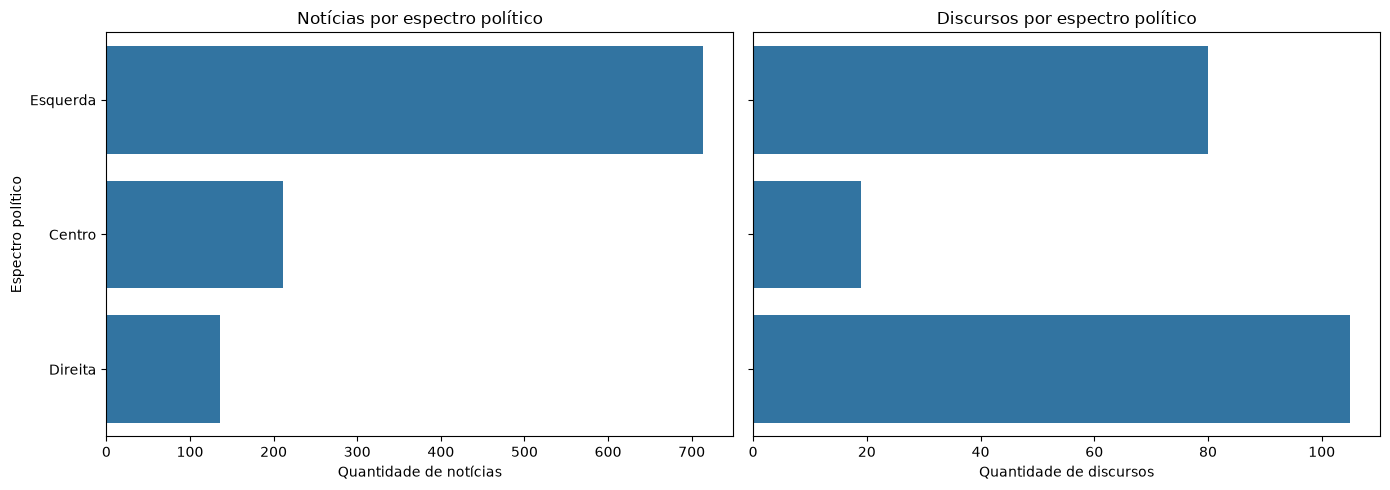

In [37]:
spectrum_order = [
    "Esquerda",
    "Centro",
    "Direita",
]

spectrum_map = {
    "Extrema-esquerda": "Esquerda",
    "Esquerda": "Esquerda",
    "Centro-esquerda": "Esquerda",
    "Centro": "Centro",
    "Centro-direita": "Direita",
    "Direita": "Direita",
    "Extrema-direita": "Direita",
}

discourse_df["political_spectrum"] = discourse_df["political_spectrum"].replace(spectrum_map)
news_df["espectro_politico"] = news_df["espectro_politico"].replace(spectrum_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.countplot(
    data=news_df,
    y="espectro_politico",
    order=spectrum_order,
    ax=axes[0],
)
axes[0].set_title("Notícias por espectro político")
axes[0].set_xlabel("Quantidade de notícias")
axes[0].set_ylabel("Espectro político")

sns.countplot(
    data=discourse_df,
    y="political_spectrum",
    order=spectrum_order,
    ax=axes[1],
)
axes[1].set_title("Discursos por espectro político")
axes[1].set_xlabel("Quantidade de discursos")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### 2.5. Termos que mais diferenciam cada espectro

Para cada espectro, compara-se o TF-IDF médio de cada termo nos argumentos daquele espectro com o TF-IDF médio nos demais. Os argumentos usados são os mascaradaos, para que o nome do partido não apareça como termo característico.

In [38]:
sw = { unicodedata.normalize("NFC", p.lower()) for p in stopwords.words("portuguese") }

vectorizer_terms = TfidfVectorizer(token_pattern = r"(?u)\b\w+\b", ngram_range = (1, 2), min_df = 3)

X_terms = vectorizer_terms.fit_transform(
    discourse_df["argument_masked"].apply(lambda t: preprocessing_text(t, sw))
)

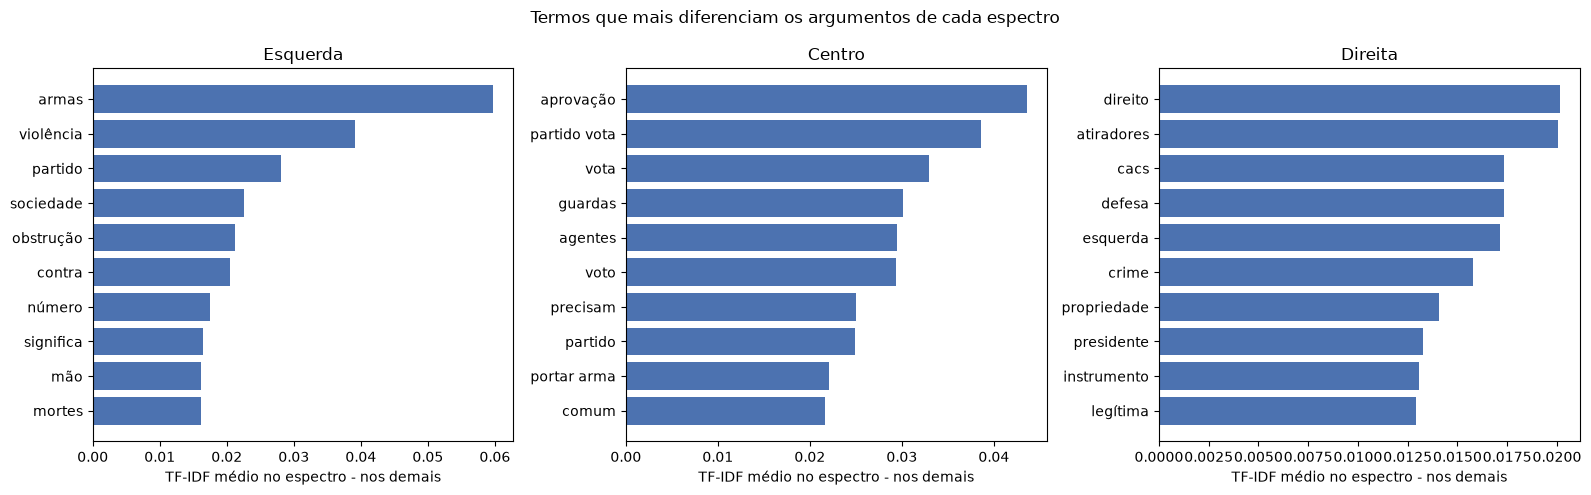

In [39]:
terms = vectorizer_terms.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize = (16, 5))

for ax, spectrum in zip(axes, spectrum_order):
    in_class = (discourse_df["political_spectrum"] == spectrum).to_numpy()

    score = np.asarray(X_terms[in_class].mean(axis = 0) - X_terms[~in_class].mean(axis = 0)).ravel()
    top = pd.Series(score, index = terms).nlargest(10).sort_values()

    ax.barh(top.index, top.values, color = "#4C72B0")
    ax.set_title(spectrum)
    ax.set_xlabel("TF-IDF médio no espectro - nos demais")

plt.suptitle("Termos que mais diferenciam os argumentos de cada espectro")
plt.tight_layout()
plt.show()

## 3. Geração de Embeddings

In [ ]:
# set_seed(34)

In [ ]:
# device = "cpu" # torch.device("cuda" if torch.cuda.is_available() else "cpu");
# print(f"Hardware utilizado: {device}");

Hardware utilizado: cpu


In [ ]:
# model = "neuralmind/bert-large-portuguese-cased";
# tokenizer = AutoTokenizer.from_pretrained(model);
# bertimbau = AutoModel.from_pretrained(model).to(device);
# max_length = bertimbau.config.max_position_embeddings;

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 16980.64it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-large-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 3.1. Tokenização e obtenção dos embeddings

In [ ]:
# def tokenize(texts: list[str], max_length, device):
#     return tokenizer(texts, padding=True, truncation=True, return_tensors="pt", max_length=max_length).to(device);

In [ ]:
# def mean_pooling(model_output, attention_mask):
#     token_embeddings = model_output.last_hidden_state;
#     input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float();

#     return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9);

#### 3.1.1. Discursos

In [ ]:
# arguments = discourse_df["argument_masked"].tolist();
# argument_embedding_bacthes = []
# batch_size = 8

# with torch.no_grad():
#     for start in range(0, len(arguments), batch_size):
#         batch_texts = arguments[start:start + batch_size]

#         batch_tokens = tokenize(batch_texts, max_length, device)
#         batch_output = bertimbau(**batch_tokens)

#         argument_embedding_bacthes.append(
#             mean_pooling(batch_output, batch_tokens["attention_mask"]).cpu()
#         )

In [ ]:
# argument_embeddings = torch.cat(argument_embedding_bacthes, dim = 0)

In [ ]:
# embedding_artifact = {
#     "embeddings": argument_embeddings.cpu(),
#     "ids": discourse_df["id"].tolist(),
#     "political_spectrum": discourse_df["political_spectrum"].tolist(),
# }

# torch.save(embedding_artifact, "content/argument_embeddings.pt")
# print(f"Embeddings salvos: {argument_embeddings.shape}")

Embeddings salvos: torch.Size([204, 1024])


#### 3.1.2. Notícias

In [48]:
news_df["news_id"] = [str(uuid.uuid5(uuid.NAMESPACE_URL, link)) for link in news_df["link"]]

print(f"IDs únicos atribuídos: {news_df['news_id'].nunique()}")
news_df[["news_id", "titulo", "partido"]].head()

IDs únicos atribuídos: 1061


,news_id,titulo,partido
0,7bf42b12-3464-58b8-ba1c-6b66de079010,Câmara dos Deputados aprova aumento da pena de...,AVANTE
1,4455f72e-743f-5c1c-a3db-3e730a5b6cb6,Manaus reforça liderança nacional em segurança...,AVANTE
2,0227023d-eae0-59bb-8d0e-6d4ed9a00c13,Deputada federal Greyce Elias é relatora de PL...,AVANTE
3,31be4488-08d2-5829-b6a1-f6fba56f9c68,Projeto da deputada Greyce Elias permite uso d...,AVANTE
4,7f86b793-e86a-599f-8ad2-6a70c48d08b6,Carlos Cavalcante cobra maior policiamento,AVANTE


In [49]:
news_df["news_text"] = (
    news_df["titulo"].str.strip() + ". " + news_df["texto_cru"].str.strip()
).str.strip()

print(f"Notícias carregadas: {len(news_df)}")
news_df[["titulo", "partido", "news_text"]].head(2)

Notícias carregadas: 1061


,titulo,partido,news_text
0,Câmara dos Deputados aprova aumento da pena de...,AVANTE,Câmara dos Deputados aprova aumento da pena de...
1,Manaus reforça liderança nacional em segurança...,AVANTE,Manaus reforça liderança nacional em segurança...


In [50]:
# news_texts = news_df["news_text"].tolist()
# news_embeddings_batches = []
# batch_size = 8

# with torch.no_grad():
#     for start in range(0, len(news_texts), batch_size):
#         batch_texts = news_texts[start:start + batch_size]
#         batch_tokens = tokenize(batch_texts, max_length, device)
#         batch_output = bertimbau(**batch_tokens)
#         batch_embeddings = mean_pooling(
#             batch_output,
#             batch_tokens["attention_mask"]
#         )
#         news_embeddings_batches.append(batch_embeddings.cpu())

# news_embeddings = torch.cat(news_embeddings_batches, dim=0)
# print(f"Embeddings das notícias: {tuple(news_embeddings.shape)}")

In [51]:
# news_embedding_artifact = {
#     "embeddings": news_embeddings,
#     "ids": news_df["news_id"].tolist(),
#     "political_spectrum": news_df["espectro_politico"].tolist(),
# }

# torch.save(news_embedding_artifact, "content/news_embeddings.pt")
# print("Embeddings salvos em content/news_embeddings.pt")

## 4. Classificação do espectro político

A primeira tarefa supervisionada será classificar os discursos em três faixas.

- **Esquerda**: Extrema-Esquerda, Esquerda e Centro-esquerda
- **Centro**: Centro
- **Direita**: Centro-direita, Direita e Extrema-direita

O baseline será uma aplicação do modelo Linear SVC sob os dados coletados de TF-IDF. A comparação será feita a partir do uso do mesmo modelo sob o emprego dos embeddings previamente coletados. A divisão entre cada embedding está no próprio id que identifica a notícia ou o discurso, sendo que cada embedding também carrega o espectro político do partido ao qual o texto está associado.

A ideia é que, com base na proximidade de argumentos com notícias que explicitam um posicionamento político, seja possível dizer se um deputado, com a sua fala, se situa próximo de posições que são do mesmo espectro político que o partido do parlamentar.

### 4.1. Carregando os embeddings

In [52]:
def load_pt(path):
    data = torch.load(path, map_location = "cpu", weights_only=False)
    return data["embeddings"].float().numpy(), data["ids"]

In [53]:
X_news_emb, news_ids = load_pt("content/news_embeddings.pt")
X_arg_emb, arg_ids = load_pt("content/argument_embeddings.pt")

In [54]:
assert news_ids == news_df["news_id"].tolist()
assert arg_ids == discourse_df["id"].tolist()

In [55]:
y_news = news_df["espectro_politico"]
y_arg = discourse_df["political_spectrum"]
groups_news = news_df["partido"]

### 4.2. Representações

**TF-IDF**: os dados de TF-IDF serão calculados. O vocabulário é aprendido somente com as notícias e reaproveitado para os argumentos.

**Embeddings**: os embeddings passarão pela normalização L2, para garantir que a extensão de um argumento não influencie durante o treinamento do modelo.

In [56]:
sw = { unicodedata.normalize("NFC", p.lower()) for p in stopwords.words("portuguese") }

news_clean = news_df["news_text"].apply(lambda t: preprocessing_text(t, sw))
arg_clean = discourse_df["argument_masked"].apply(lambda t: preprocessing_text(t, sw))

vectorizer = TfidfVectorizer(token_pattern = r"(?u)\b\w+\b")
X_news_tfidf = vectorizer.fit_transform(news_clean)
X_arg_tfidf = vectorizer.transform(arg_clean)

In [57]:
normalizer = Normalizer(norm="l2")

X_news_emb = normalizer.transform(X_news_emb)
X_arg_emb = normalizer.transform(X_arg_emb)

### 4.3. Treinamento nas notícias e teste nos argumentos

O mesmo Linear SVC é treinado com as notícias em cada representação e prevê o espectro dos argumentos dos deputados. Como há muito mais notícias de esquerda, `class_weight="balanced"` dá a cada espectro o mesmo peso no treino.

O hiperparâmetro `C` é escolhido por grid search com validação cruzada **somente nas notícias**; os argumentos ficam reservados para o teste. As dobras são agrupadas por partido (`StratifiedGroupKFold`): as notícias de um partido nunca estão no treino e na validação ao mesmo tempo, então o hiperparâmetro `C` escolhido é o que melhor reconhece o espectro de partidos não vistos como acontece com os discursos.

In [58]:
def train_and_evaluate(name, X_train, X_test):
    grid = GridSearchCV(
        LinearSVC(class_weight = "balanced", max_iter = 10000, random_state = 34),
        param_grid = { "C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100] },
        scoring = "balanced_accuracy",
        cv = StratifiedGroupKFold(n_splits = 5, shuffle = True, random_state = 34)
    )

    grid.fit(X_train, y_news, groups = groups_news)
    pred = grid.predict(X_test)

    print(name)
    print(f"Melhor C: {grid.best_params_['C']}")
    print(f"Acurácia balanceada na validação (notícias): {grid.best_score_:.3f}")
    print(f"Acurácia balanceada no teste (argumentos): {balanced_accuracy_score(y_arg, pred):.3f}")
    print(classification_report(y_arg, pred, labels = spectrum_order, zero_division = 0))

    return pred

In [59]:
discourse_df["pred_tfidf"] = train_and_evaluate("TF-IDF + LinearSVC (baseline)", X_news_tfidf, X_arg_tfidf)
discourse_df["pred_embedding"] = train_and_evaluate("BERTimbau + LinearSVC", X_news_emb, X_arg_emb)

TF-IDF + LinearSVC (baseline)
Melhor C: 1
Acurácia balanceada na validação (notícias): 0.449
Acurácia balanceada no teste (argumentos): 0.374
              precision    recall  f1-score   support

    Esquerda       0.39      0.91      0.55        80
      Centro       0.22      0.21      0.22        19
     Direita       0.00      0.00      0.00       105

    accuracy                           0.38       204
   macro avg       0.21      0.37      0.26       204
weighted avg       0.18      0.38      0.24       204

BERTimbau + LinearSVC
Melhor C: 10
Acurácia balanceada na validação (notícias): 0.591
Acurácia balanceada no teste (argumentos): 0.465
              precision    recall  f1-score   support

    Esquerda       0.45      0.85      0.59        80
      Centro       0.20      0.53      0.29        19
     Direita       1.00      0.02      0.04       105

    accuracy                           0.39       204
   macro avg       0.55      0.47      0.30       204
weighted avg    

### 4.4. O argumento está alinhado ao espectro do deputado?

In [60]:
discourse_df["alinhado"] = discourse_df["pred_embedding"] == discourse_df["political_spectrum"]
discourse_df[["deputy_name", "party", "political_spectrum", "pred_tfidf", "pred_embedding", "alinhado"]].head(20)

,deputy_name,party,political_spectrum,pred_tfidf,pred_embedding,alinhado
0,Severino Ninho,PSB,Esquerda,Centro,Esquerda,True
1,Izalci,PSDB,Centro,Centro,Centro,True
2,Rubens Bueno,PPS,Esquerda,Centro,Centro,False
3,Arlindo Chinaglia,PT,Esquerda,Esquerda,Esquerda,True
4,Jandira Feghali,PCDOB,Esquerda,Esquerda,Centro,False
5,Dr. Carlos Alberto,PMN,Centro,Esquerda,Centro,True
6,Afonso Hamm,PP,Direita,Esquerda,Centro,False
7,Vieira da Cunha,PDT,Esquerda,Centro,Centro,False
8,Efraim Filho,DEM,Direita,Centro,Centro,False
9,Eliene Lima,PSD,Centro,Centro,Centro,True
